In [67]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline  

In [2]:
#The Central Limit Theorem says that when you take many samples from a dataset (like churn data), 
#the distribution of their average values becomes approximately normal (bell-shaped), even if the original data isn’t.
#The Central Limit Theorem is useful because it lets you treat sample averages as normally distributed, even if your original data isn’t.

In [17]:
data = pd.read_csv('churn_prediction.csv')

In [19]:
data.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [7]:
population = data['vintage']

* consider population the values of vintage feature from our churn prediction problem

In [9]:
population = pd.DataFrame(population)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fa58369beb8>]],
      dtype=object)

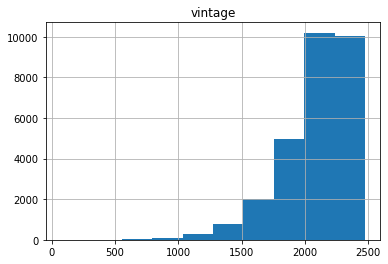

In [ ]:
population.hist(bins=10)

* The distribution of vintage is Left(Negative) Skewed

In [ ]:
population['vintage'].mean()

2091.1441054189277

* The mean value of vintage feature is around 2091

In [27]:
# Create a list
sampled_means = []

# For 1000  times,
for i in range(0,1000):
    # Take a random sample of 100 rows from the population, take the mean of those rows, append to sampled_means
    sampled_means.append(population.sample(n=100).mean().values[0])

print(len(sampled_means))

1000


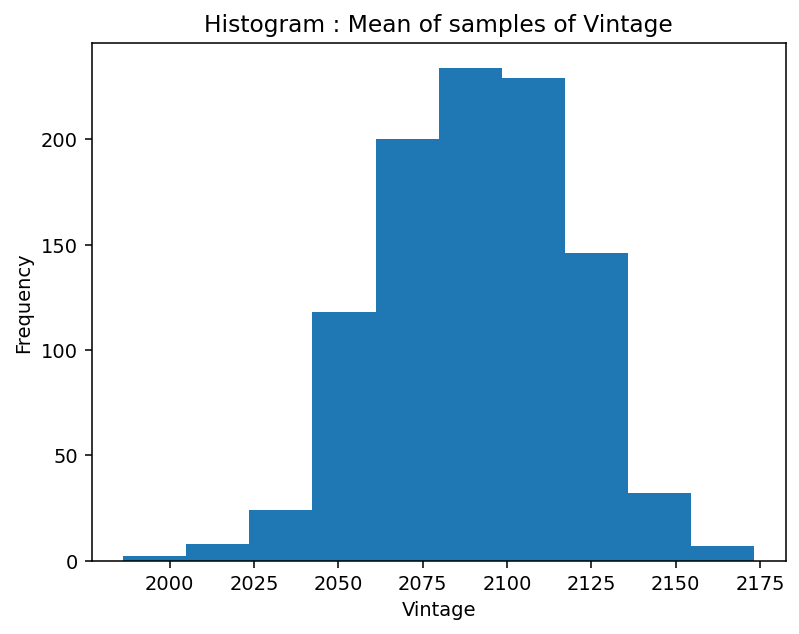

In [35]:
# plotting histogram
plt.figure(dpi = 140)
plt.hist(sampled_means)

plt.xlabel("Vintage")
plt.ylabel('Frequency')
plt.title("Histogram : Mean of samples of Vintage")
plt.show()

In [ ]:
* 100 Samples of 100 datapoints were taken 
* Mean of the random samples actully follow the Normal Distribution
* Central Limit Theorem  can be verified by using KDE as well 

In [ ]:
# View the mean of the sampled_means
pd.Series(sampled_means).mean()

2091.2601600000003

In [ ]:
# Subtract Mean Sample Mean From True Population Mean
error = population['vintage'].mean() - pd.Series(sampled_means).mean()

# Print
print('The Mean Sample Mean is only %f different the True Population mean!' % error)

The Mean Sample Mean is only -0.116055 different the True Population mean!


In [37]:
data = pd.read_csv('titanic.csv')

In [39]:
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [51]:
#central limit theorem on fare
prices = data['fare']

33.29547928134557

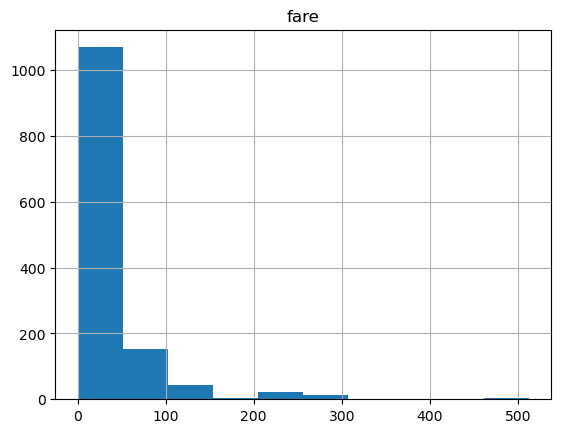

In [53]:
prices = pd.DataFrame(prices)
prices.hist(bins=10)
prices['fare'].mean()

In [55]:
sampled_means = []

# For 1000  times,
for i in range(0,1000):
    # Take a random sample of 100 rows from the population, take the mean of those rows, append to sampled_means
    sampled_means.append(prices.sample(n=100).mean().values[0])

print(len(sampled_means))

1000


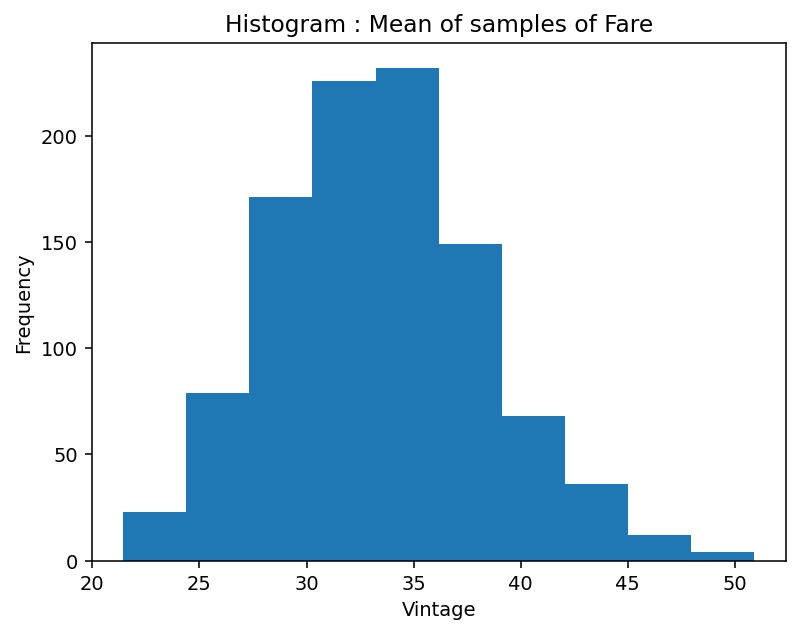

In [59]:
# plotting histogram
plt.figure(dpi = 140)
plt.hist(sampled_means)

plt.xlabel("Vintage")
plt.ylabel('Frequency')
plt.title("Histogram : Mean of samples of Fare")
plt.show()
#This looks like a normal distribution

In [61]:
pd.Series(sampled_means).mean()

33.39003326878788

In [63]:
error = prices['fare'].mean() - pd.Series(sampled_means).mean()

# Print
print('The Mean Sample Mean is only %f different the True Fare mean!' % error)

The Mean Sample Mean is only -0.094554 different the True Fare mean!


<Axes: ylabel='Density'>

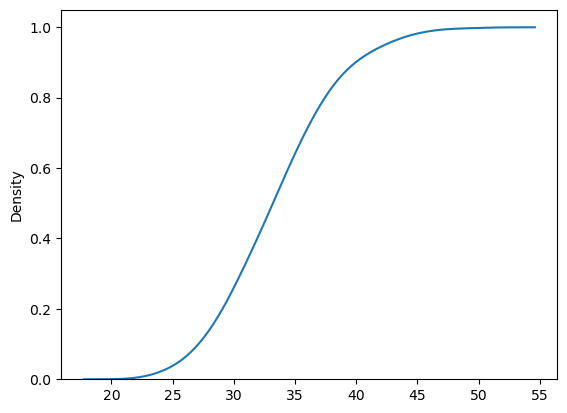

In [73]:
#KDE Plot
sns.kdeplot(sampled_means,cumulative=True)